
# Iris Dataset: Exploratory Data Analysis and Visualization

## Problem Statement
The objective of this notebook is to explore and visualize the famous Iris dataset using Python libraries such as pandas, matplotlib, and seaborn.

This notebook focuses on:
- Loading and understanding the dataset
- Performing exploratory data analysis (EDA)
- Visualizing feature relationships and distributions
- Detecting patterns and outliers
- Understanding how EDA supports future machine learning workflows

Additionally, ML Model is included to demonstrate how exploratory analysis connects with predictive modeling.


In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_style("whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.



# Load the Dataset
The Iris dataset contains measurements of iris flowers belonging to three different species:
- Iris-setosa
- Iris-versicolor
- Iris-virginica

Features:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width


In [2]:

df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')

print("Dataset loaded successfully.")


Dataset loaded successfully.



# Initial Dataset Inspection
This section helps us understand:
- dataset dimensions
- feature names
- sample records


In [3]:

print("Shape of Dataset:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst Five Rows:")
display(df.head())


Shape of Dataset: (150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

First Five Rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:

print("Last Five Rows:")
display(df.tail())

print("\nRandom Sample Rows:")
display(df.sample(5, random_state=42))


Last Five Rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica



Random Sample Rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
73,74,6.1,2.8,4.7,1.2,Iris-versicolor
18,19,5.7,3.8,1.7,0.3,Iris-setosa
118,119,7.7,2.6,6.9,2.3,Iris-virginica
78,79,6.0,2.9,4.5,1.5,Iris-versicolor
76,77,6.8,2.8,4.8,1.4,Iris-versicolor



# Dataset Information
We use:
- `.info()` to inspect datatypes and missing values
- `.describe()` for statistical summaries


In [5]:

print("Dataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:

print("Statistical Summary:")
display(df.describe())


Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000



# Data Cleaning Checks
Before analysis, it is important to verify:
- missing values
- duplicate rows


In [7]:

print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values:


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


Duplicate Rows: 0



# Class Distribution
This shows how samples are distributed across species.
Balanced datasets are generally better for machine learning.


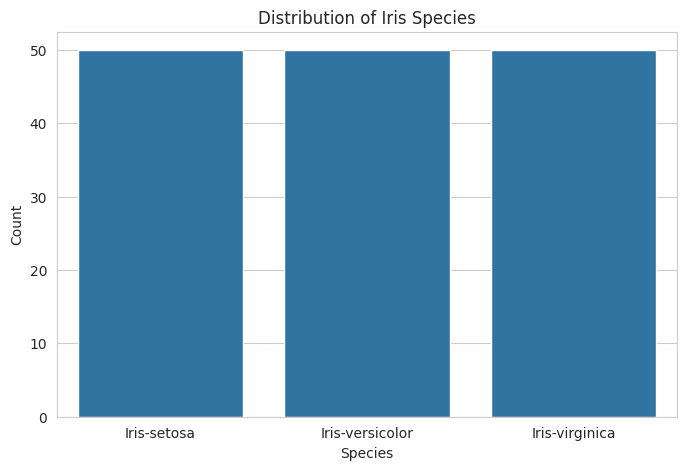

In [8]:

plt.figure(figsize=(8,5))

sns.countplot(x='Species', data=df)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()



# Scatter Plot Visualization
Scatter plots help identify relationships between features.

Petal features are especially useful for separating iris species.


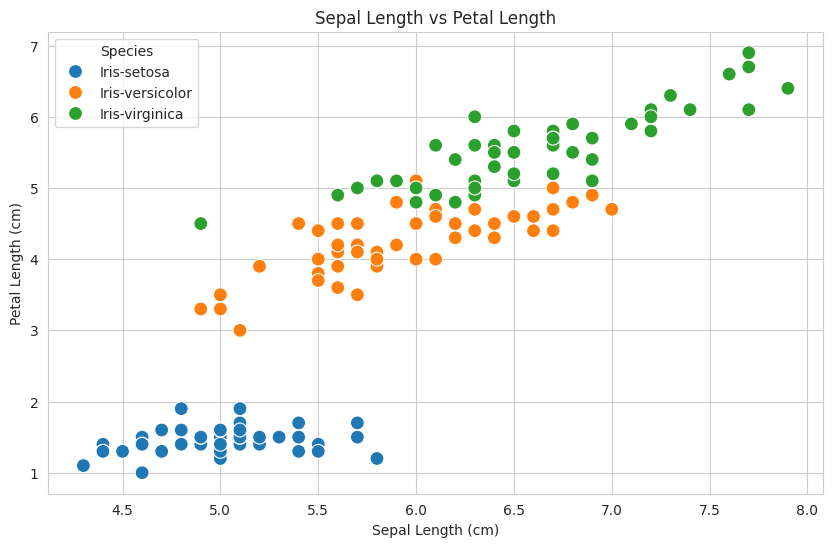

In [9]:
# Scatterplot: Petal Dimensions
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='SepalLengthCm',
    y='PetalLengthCm',
    hue='Species',
    data=df,
    s=100
)

plt.title("Sepal Length vs Petal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")

plt.show()



# Pairplot Visualization
Pairplots provide a complete feature relationship overview.

This is one of the most powerful visualizations for the Iris dataset.


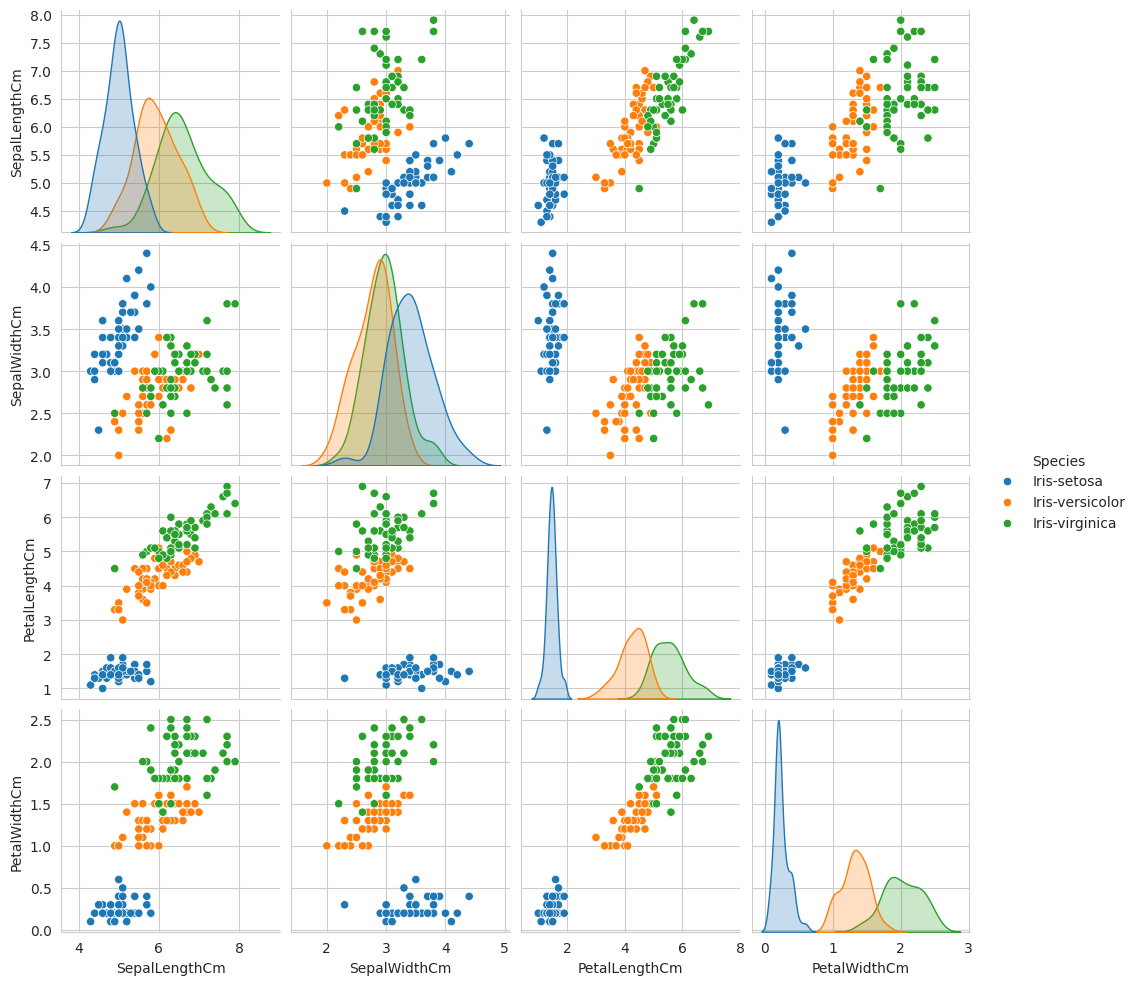

In [10]:
sns.pairplot(df.drop('Id', axis=1), hue='Species')

plt.show()



# Histograms
Histograms help us understand:
- distributions
- skewness
- spread of values


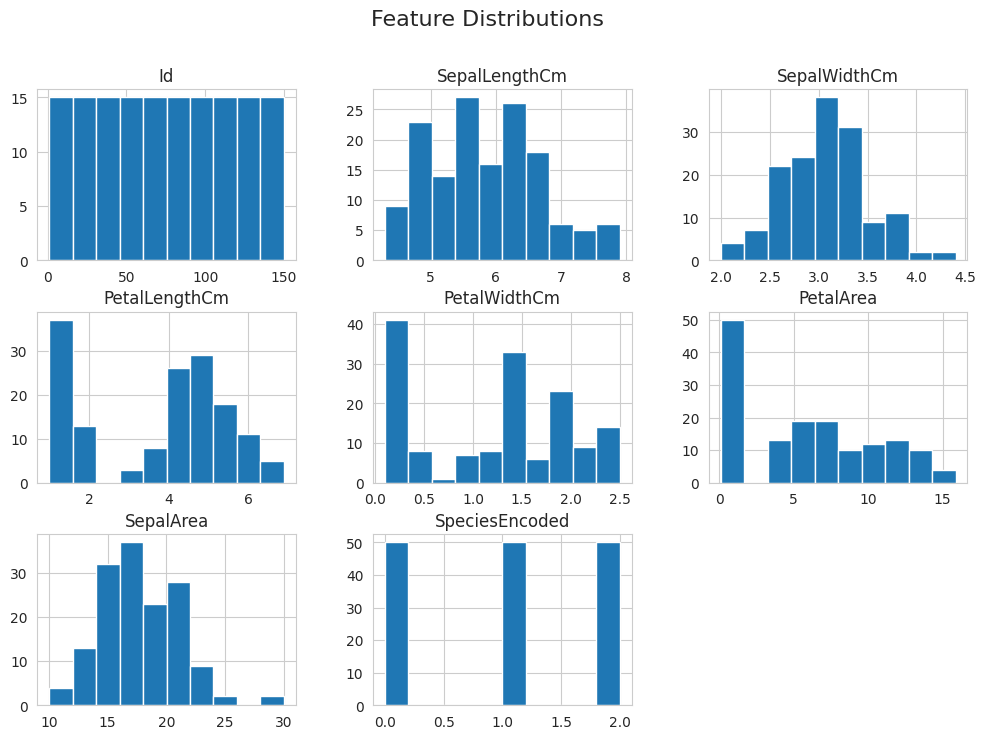

In [37]:

df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions", fontsize=16)

plt.show()


# Box Plots
Box plots help identify:
- median
- quartiles
- spread
- potential outliers


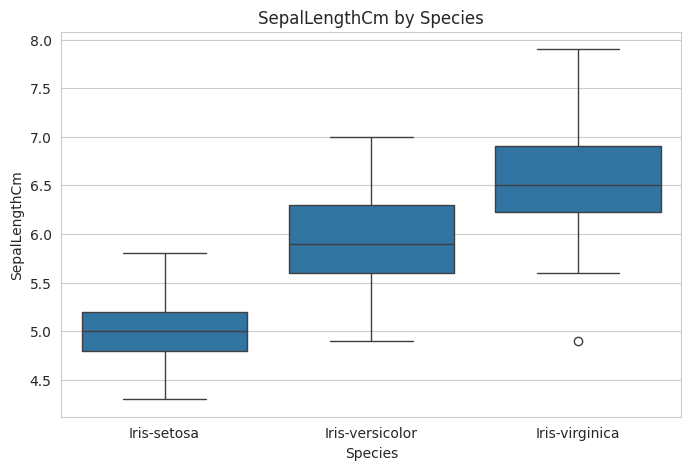

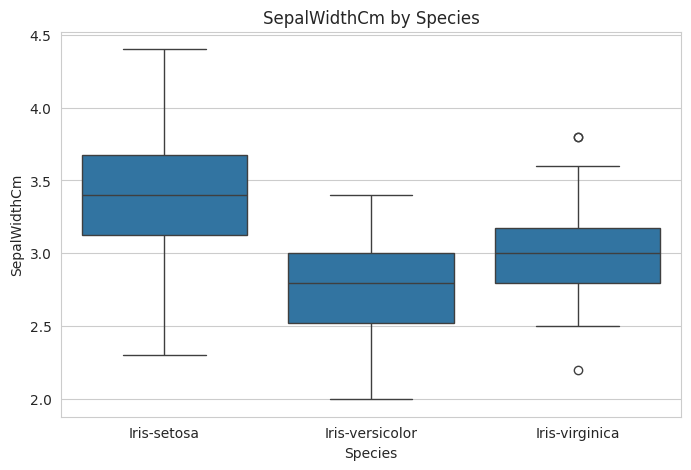

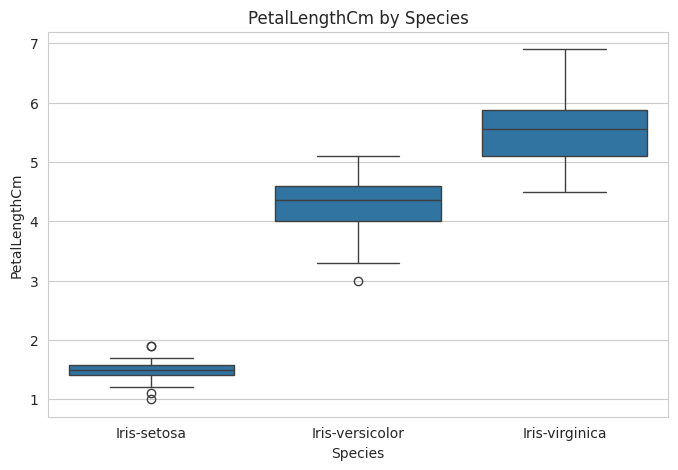

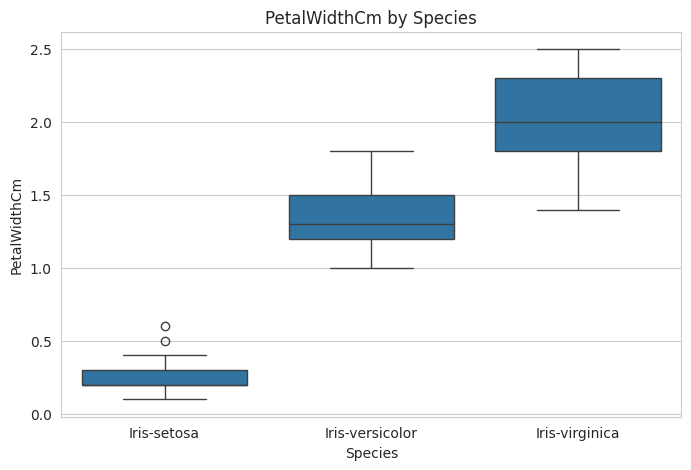

In [32]:

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for feature in features:
    plt.figure(figsize=(8,5))
    
    sns.boxplot(x='Species', y=feature, data=df)
    
    plt.title(f'{feature} by Species')
    plt.show()



# Correlation Heatmap
Correlation analysis helps identify strongly related features.

Values close to:
- +1 indicate strong positive correlation
- -1 indicate strong negative correlation
- 0 indicate weak correlation


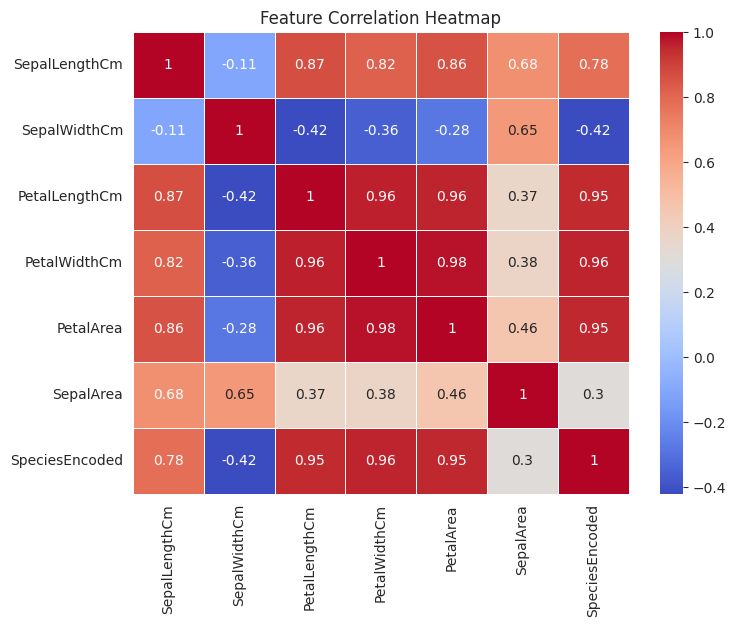

In [29]:

plt.figure(figsize=(8,6))

correlation = df.drop('Id', axis=1).corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()


# Key Insights from EDA
- Petal length and petal width have a strong positive correlation.
- Iris-setosa is clearly separable from the other species.
- Sepal width shows comparatively weaker correlation with other features.
- Petal-based features are highly informative for classification tasks.
- The dataset is balanced across all three species.
- Only a few minor outliers are visible in sepal-related measurements.

These insights demonstrate why exploratory data analysis is a critical step before applying machine learning models.


**Extra Work**


## Feature Engineering
We create simple engineered features:
- Petal Area
- Sepal Area

This demonstrates feature understanding and ML thinking.


In [14]:
# Creating mathematically meaningful features that highlight domain understanding
df['PetalArea'] = df['PetalLengthCm'] * df['PetalWidthCm']
df['SepalArea'] = df['SepalLengthCm'] * df['SepalWidthCm']

print("Engineered features added (PetalArea, SepalArea).")
display(df.head())

Engineered features added (PetalArea, SepalArea).


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,PetalArea,SepalArea
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0.28,17.85
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0.28,14.70
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0.26,15.04
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0.30,14.26
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0.28,18.00



## Label Encoding
Machine learning models require numerical labels.


In [15]:

encoder = LabelEncoder()

df['SpeciesEncoded'] = encoder.fit_transform(df['Species'])
print("Target variable encoded.")
display(df[['Species', 'SpeciesEncoded']].head())


Target variable encoded.


,Species,SpeciesEncoded
0,Iris-setosa,0
1,Iris-setosa,0
2,Iris-setosa,0
3,Iris-setosa,0
4,Iris-setosa,0



## Train-Test Split
The dataset is divided into:
- training data
- testing data


In [16]:

X = df.drop(['Species', 'SpeciesEncoded'], axis=1)
y = df['SpeciesEncoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (120, 7)
Testing Shape: (30, 7)



## Logistic Regression Model
Logistic Regression is a strong baseline classification model for structured datasets like Iris.


In [27]:

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.



## Model Evaluation
We evaluate the model using:
- Accuracy Score
- Confusion Matrix


In [21]:

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 1.00


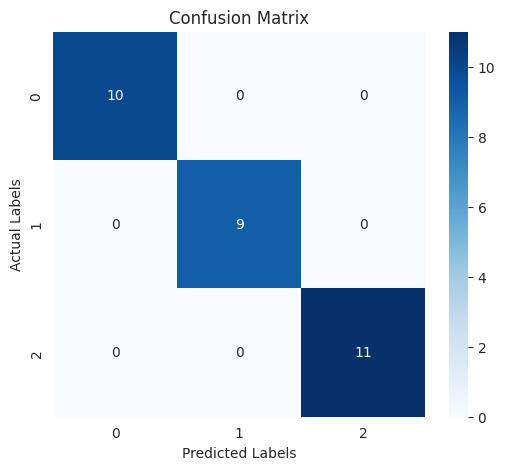

In [24]:

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

plt.show()



# Final Conclusion

In this notebook, we:
- loaded and inspected the Iris dataset,
- explored statistical summaries,
- visualized distributions and feature relationships,
- identified correlations and outliers,
- extracted meaningful insights from EDA.

Additionally, a small machine learning preview demonstrated how exploratory analysis supports predictive modeling.
